# Etapa 01 — ¿Cómo se conectan clima, operación y decisiones?

Consulta el dossier. Predice, calcula, explica y juzga el alcance antes de registrar tu decisión.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
# Encuentra la raíz tanto desde la carpeta del notebook como desde la raíz del libro.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'sa_mise' / '__init__.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from sa_mise import datos, modelos, expediente
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})

In [2]:
from sa_mise import sector
CASO='ejemplo_docente'
# Usa el mismo identificador de tu equipo en las ocho etapas.

## 1. Asociación observada y una explicación rival
El porcentaje de embalse se transforma desde fracción 0–1. El precio se conserva nominal y positivo antes de tomar logaritmo. Retiramos efectos aditivos de año y mes en ambas variables para comparar asociaciones.

{'meses': 264,
 'correlacion_bruta': -0.3654022452929349,
 'correlacion_residual': -0.5459860648178948,
 'interpretacion': 'Asociación; controles aditivos no identifican causalidad ni corrigen toda no estacionariedad'}

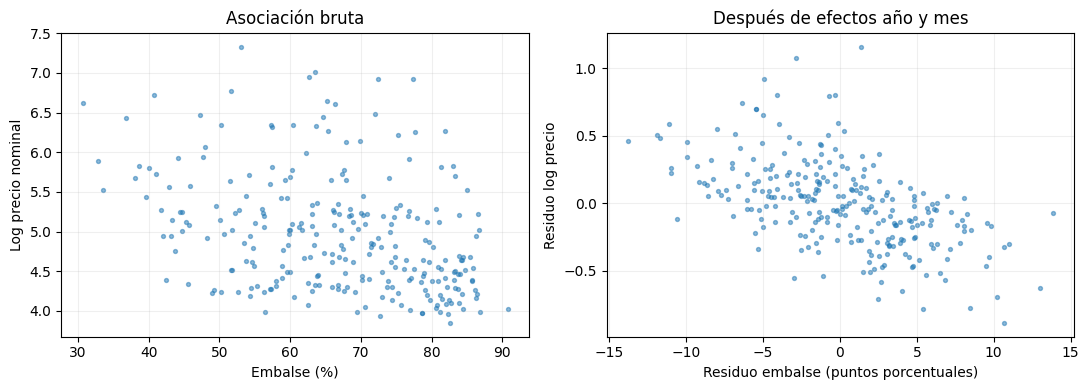

In [3]:
mensual,asociacion=sector.asociacion_hidrologica();display(asociacion)
fig,axs=plt.subplots(1,2,figsize=(11,4))
axs[0].scatter(mensual.embalse_pct,mensual.log_precio,s=8,alpha=.5);axs[0].set(xlabel='Embalse (%)',ylabel='Log precio nominal',title='Asociación bruta')
axs[1].scatter(mensual.embalse_pct_residuo,mensual.log_precio_residuo,s=8,alpha=.5);axs[1].set(xlabel='Residuo embalse (puntos porcentuales)',ylabel='Residuo log precio',title='Después de efectos año y mes')
plt.tight_layout();plt.show()

Compara signo y dispersión. Un cambio sugiere que la agregación mezclaba componentes; persistencia no elimina variables omitidas ni simultaneidad. El control por año no equivale a deflactar cada observación. Formula una hipótesis de mecanismo y una rival antes de recomendar una intervención.

## 2. Del diagrama a una pregunta contrastable
Esta tabla es una plantilla argumentada, no un registro de relaciones demostradas. Completa fuente y evidencia adversa para tu encargo.

In [4]:
lazos=pd.DataFrame([
 ['Aportes → agua disponible','+','Operación, almacenamiento y conversión','Aportes/estado/descargas por período'],
 ['Holgura → precio esperado','−','Reglas de mercado, contratos y expectativas','Precios, disponibilidad, demanda y decisiones'],
 ['Precio esperado → inicio de proyectos','+ supuesto','Financiación y expectativas de otros actores','Fechas de decisión y presupuestos'],
 ['Pipeline conocido → nuevos inicios','− supuesto','Anticipación y credibilidad','Registro de proyectos y revisión de expectativas']
],columns=['relacion','polaridad','condicion','dato_para_contrastar'])
display(lazos)

,relacion,polaridad,condicion,dato_para_contrastar
0,Aportes → agua disponible,+,"Operación, almacenamiento y conversión",Aportes/estado/descargas por período
1,Holgura → precio esperado,−,"Reglas de mercado, contratos y expectativas","Precios, disponibilidad, demanda y decisiones"
2,Precio esperado → inicio de proyectos,+ supuesto,Financiación y expectativas de otros actores,Fechas de decisión y presupuestos
3,Pipeline conocido → nuevos inicios,− supuesto,Anticipación y credibilidad,Registro de proyectos y revisión de expectativas


Un signo no cuantifica un efecto. Completa el lazo y especifica las demoras. Si tu destinatario no controla una variable, debe quedar como condición o incertidumbre, no como palanca disponible.

## Registrar el avance del equipo
Sustituye el campo de decisión por tu razonamiento y conserva el nivel de evidencia. El identificador es el mismo durante todo el caso.

In [5]:
decision_estudiante='POR COMPLETAR'
expediente.registrar(CASO,'identidad','Asociaciones mensuales: '+str(asociacion),'descripcion' if 1 in [0,1] else 'exploracion',
 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
 decision_estudiante)

Out[5]: 
{'version': 2,
 'caso': 'ejemplo_docente',
 'etapas': {'evidencia': {'hallazgo': 'Año 2024: generación 83262.923 GWh y pico 11704.365 MW; son magnitudes diferentes',
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
   'limite': 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
   'decision_estudiante': 'POR COMPLETAR'},
  'identidad': {'hallazgo': "Asociaciones mensuales: {'meses': 264, 'correlacion_bruta': -0.3654022452929349, 'correlacion_residual': -0.5459860648178948, 'interpretacion': 'Asociación; controles aditivos no identifican causalidad ni corrigen toda no estacionariedad'}",
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícit